In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings 
warnings.filterwarnings('ignore')

import dataset

In [2]:
df = pd.read_csv('data_salaries.csv')
print(df.shape)
df.head(5)

(148654, 13)


,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.0,56120.71,198306.9,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737.0,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN


# Explore data 

In [3]:
df.tail()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
148649,148650,Roy I Tillery,Custodian,0.00,0.00,0.00,0.00,0.00,0.00,2014,NaN,San Francisco,PT
148650,148651,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,NaN,San Francisco,NaN
148651,148652,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,NaN,San Francisco,NaN
148652,148653,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,NaN,San Francisco,NaN
148653,148654,Joe Lopez,"Counselor, Log Cabin Ranch",0.00,0.00,-618.13,0.00,-618.13,-618.13,2014,NaN,San Francisco,PT


In [4]:
df.describe()

,Id,TotalPay,TotalPayBenefits,Year,Notes
count,148654.000000,148654.000000,148654.000000,148654.000000,0.0
mean,74327.500000,74768.321972,93692.554811,2012.522643,NaN
std,42912.857795,50517.005274,62793.533483,1.117538,NaN
min,1.000000,-618.130000,-618.130000,2011.000000,NaN
25%,37164.250000,36168.995000,44065.650000,2012.000000,NaN
50%,74327.500000,71426.610000,92404.090000,2013.000000,NaN
75%,111490.750000,105839.135000,132876.450000,2014.000000,NaN
max,148654.000000,567595.430000,567595.430000,2014.000000,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                148654 non-null  int64  
 1   EmployeeName      148654 non-null  str    
 2   JobTitle          148654 non-null  str    
 3   BasePay           148049 non-null  object 
 4   OvertimePay       148654 non-null  object 
 5   OtherPay          148654 non-null  object 
 6   Benefits          112495 non-null  object 
 7   TotalPay          148654 non-null  float64
 8   TotalPayBenefits  148654 non-null  float64
 9   Year              148654 non-null  int64  
 10  Notes             0 non-null       float64
 11  Agency            148654 non-null  str    
 12  Status            38119 non-null   str    
dtypes: float64(3), int64(2), object(4), str(4)
memory usage: 14.7+ MB


# Data Cleaning

In [6]:
df['Id'].unique()

df.duplicated().sum()

np.int64(0)

In [7]:
# Drop column Id and Notes

df = df.drop(['Id','Notes'], axis=1)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   EmployeeName      148654 non-null  str    
 1   JobTitle          148654 non-null  str    
 2   BasePay           148049 non-null  object 
 3   OvertimePay       148654 non-null  object 
 4   OtherPay          148654 non-null  object 
 5   Benefits          112495 non-null  object 
 6   TotalPay          148654 non-null  float64
 7   TotalPayBenefits  148654 non-null  float64
 8   Year              148654 non-null  int64  
 9   Agency            148654 non-null  str    
 10  Status            38119 non-null   str    
dtypes: float64(2), int64(1), object(4), str(4)
memory usage: 12.5+ MB


In [9]:
df['Status'].value_counts()

Status
FT    22334
PT    15785
Name: count, dtype: int64

In [10]:

df['BasePay'] = df['BasePay'].replace('Not Provided', 0)
df['BasePay'] = df['BasePay'].astype(float)

In [11]:
df

,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Agency,Status
0,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.43,567595.43,2011,San Francisco,NaN
1,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,San Francisco,NaN
2,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.91,335279.91,2011,San Francisco,NaN
3,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.9,NaN,332343.61,332343.61,2011,San Francisco,NaN
4,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.0,182234.59,NaN,326373.19,326373.19,2011,San Francisco,NaN
...,...,...,...,...,...,...,...,...,...,...,...
148649,Roy I Tillery,Custodian,0.00,0.00,0.00,0.00,0.00,0.00,2014,San Francisco,PT
148650,Not provided,Not provided,0.00,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,San Francisco,NaN
148651,Not provided,Not provided,0.00,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,San Francisco,NaN
148652,Not provided,Not provided,0.00,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,San Francisco,NaN


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   EmployeeName      148654 non-null  str    
 1   JobTitle          148654 non-null  str    
 2   BasePay           148049 non-null  float64
 3   OvertimePay       148654 non-null  object 
 4   OtherPay          148654 non-null  object 
 5   Benefits          112495 non-null  object 
 6   TotalPay          148654 non-null  float64
 7   TotalPayBenefits  148654 non-null  float64
 8   Year              148654 non-null  int64  
 9   Agency            148654 non-null  str    
 10  Status            38119 non-null   str    
dtypes: float64(3), int64(1), object(3), str(4)
memory usage: 12.5+ MB


In [13]:
df['OvertimePay'].unique()

array([0.0, 245131.88, 106088.18, ..., '102.70', '56.77', 'Not Provided'],
      shape=(66555,), dtype=object)

In [14]:
# replace 'Not Provided' to 0
df['OvertimePay'] = df['OvertimePay'].replace('Not Provided',0)
# change data type of OvertimePay to float
df['OvertimePay'] = df['OvertimePay'].astype(float)

In [15]:

# replace 'Not Provided' to 0 in OtherPay column
df['OtherPay'] = df['OtherPay'].replace('Not Provided',0)
# change data type of OtherPay to float
df['OtherPay'] = df['OtherPay'].astype(float)


In [16]:

# replace 'Not Provided' to 0 in Benefits column
df['Benefits'] = df['Benefits'].replace('Not Provided',0)
# change data type of Benefits to float
df['Benefits'] = df['Benefits'].astype(float)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   EmployeeName      148654 non-null  str    
 1   JobTitle          148654 non-null  str    
 2   BasePay           148049 non-null  float64
 3   OvertimePay       148654 non-null  float64
 4   OtherPay          148654 non-null  float64
 5   Benefits          112495 non-null  float64
 6   TotalPay          148654 non-null  float64
 7   TotalPayBenefits  148654 non-null  float64
 8   Year              148654 non-null  int64  
 9   Agency            148654 non-null  str    
 10  Status            38119 non-null   str    
dtypes: float64(6), int64(1), str(4)
memory usage: 12.5 MB


In [17]:
# Check data in column Year 
df['Year'].unique()

array([2011, 2012, 2013, 2014])

In [18]:
# Change Year column to datetime data type
df['Year'] = pd.to_datetime(df['Year'])

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   EmployeeName      148654 non-null  str           
 1   JobTitle          148654 non-null  str           
 2   BasePay           148049 non-null  float64       
 3   OvertimePay       148654 non-null  float64       
 4   OtherPay          148654 non-null  float64       
 5   Benefits          112495 non-null  float64       
 6   TotalPay          148654 non-null  float64       
 7   TotalPayBenefits  148654 non-null  float64       
 8   Year              148654 non-null  datetime64[ns]
 9   Agency            148654 non-null  str           
 10  Status            38119 non-null   str           
dtypes: datetime64[ns](1), float64(6), str(4)
memory usage: 12.5 MB


In [20]:
# Check Missing values in the dataset
df.isnull().sum()

EmployeeName             0
JobTitle                 0
BasePay                605
OvertimePay              0
OtherPay                 0
Benefits             36159
TotalPay                 0
TotalPayBenefits         0
Year                     0
Agency                   0
Status              110535
dtype: int64

In [21]:
# Handle missing values in BasePay
df['BasePay'] = df['BasePay'].fillna(value=0)

In [22]:
# handle missing values in Benefits with mean values
df['Benefits'] = df['Benefits'].fillna(df['Benefits'].mean())

In [23]:
df['Status'].isnull().sum()

np.int64(110535)

In [24]:
df['Status'].unique()

<StringArray>
[nan, 'PT', 'FT']
Length: 3, dtype: str

In [25]:
df['Status'] = df['Status'].fillna('bfill')

In [26]:
df['Status'].isnull().sum()

np.int64(0)

## Handle Outliers

In [29]:
# select categorical columns
cat_cols = df.select_dtypes(include='str')
cat_cols.isnull().sum()

EmployeeName    0
JobTitle        0
Agency          0
Status          0
dtype: int64

In [30]:
# select only numerical columns
num_cols = df.select_dtypes(include=['int','float'])
num_cols.isnull().sum()

BasePay             0
OvertimePay         0
OtherPay            0
Benefits            0
TotalPay            0
TotalPayBenefits    0
dtype: int64

In [ ]:
# check for negative values in numerical columns

num_cols[num_cols<0].count() 

BasePay             11
OvertimePay          1
OtherPay             5
Benefits             4
TotalPay             1
TotalPayBenefits     4
dtype: int64

In [38]:
num_cols.tail()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
148649,0.0,0.0,0.00,0.0,0.00,0.00
148650,0.0,0.0,0.00,0.0,0.00,0.00
148651,0.0,0.0,0.00,0.0,0.00,0.00
148652,0.0,0.0,0.00,0.0,0.00,0.00
148653,0.0,0.0,618.13,0.0,618.13,618.13


In [36]:
# use abs function to convert negative values to positive values in numerical columns
num_cols = num_cols.abs()

In [37]:
# check negative values
num_cols[num_cols<0].count()

BasePay             0
OvertimePay         0
OtherPay            0
Benefits            0
TotalPay            0
TotalPayBenefits    0
dtype: int64

## Visualize Outliers

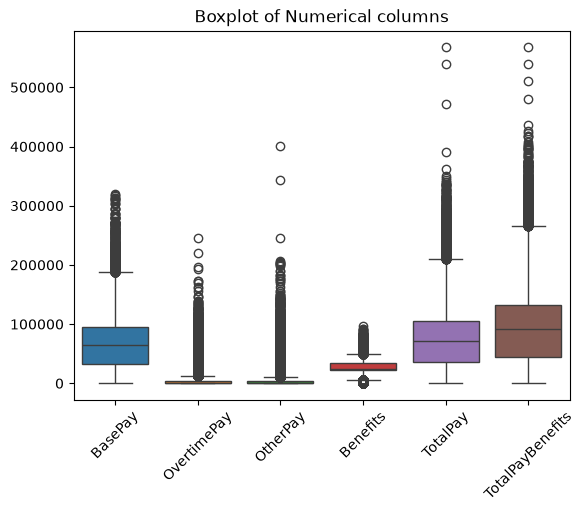

In [42]:
plt.Figure(figsize = (16,8))
sns.boxplot(data=num_cols)
plt.title('Boxplot of Numerical columns')
plt.xticks(rotation=45)
plt.show()



In [44]:
# Handling Outliers values using IQR

for col in num_cols.columns:
      Q1 = num_cols[col].quantile(0.25)
      Q3 = num_cols[col].quantile(0.75)

      IQR = Q3 - Q1

      lower_bound = Q1 - 1.2 * IQR
      upper_bound = Q3 + 1.2 * IQR

      # remove Outliers
      num_cols =  num_cols[(num_cols[col] >= lower_bound) & (num_cols[col] <= upper_bound)]


      

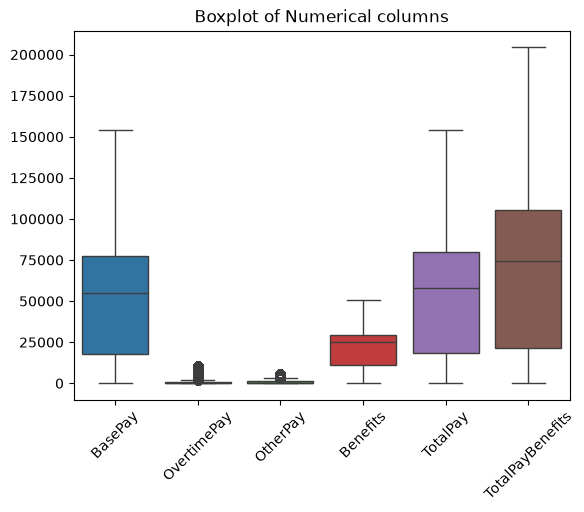

In [45]:
plt.Figure(figsize = (16,8))
sns.boxplot(data=num_cols)
plt.title('Boxplot of Numerical columns')
plt.xticks(rotation=45)
plt.show()
